In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# Load data
conn = sqlite3.connect("../superstore.db")
df = pd.read_sql("SELECT * FROM orders", conn)
conn.close()

# Basic inspection
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nFirst 5 rows:")
df.head()

Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print("\nMissing percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))

Missing values per column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Missing percentage:
Row ID           0.0
Order ID         0.0
Order Date       0.0
Ship Date        0.0
Ship Mode        0.0
Customer ID      0.0
Customer Name    0.0
Segment          0.0
Country          0.0
City             0.0
State            0.0
Postal Code      0.0
Region           0.0
Product ID       0.0
Category         0.0
Sub-Category     0.0
Product Name     0.0
Sales            0.0
Quantity         0.0
Discount         0.0
Profit           0.0
dtype: float64


In [4]:
# Statistical summary
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


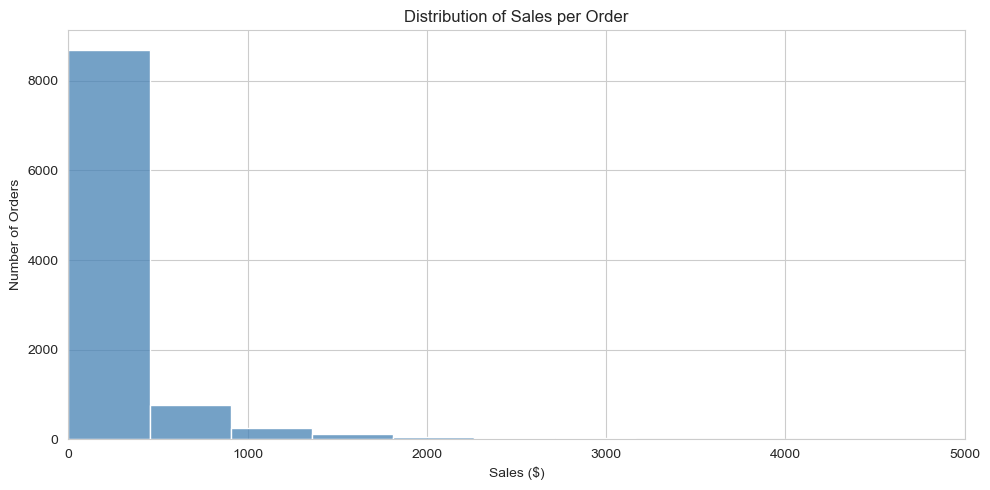

Chart 1 done


In [7]:
# Set style for all charts
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Chart 1 — Sales distribution (histogram)
plt.figure()
sns.histplot(df["Sales"], bins=50, color="steelblue")
plt.title("Distribution of Sales per Order")
plt.xlabel("Sales ($)")
plt.ylabel("Number of Orders")
plt.xlim(0, 5000)  # focus on main distribution, exclude extreme outliers
plt.tight_layout()
plt.savefig("../sales_distribution.png")
plt.show()
print("Chart 1 done")

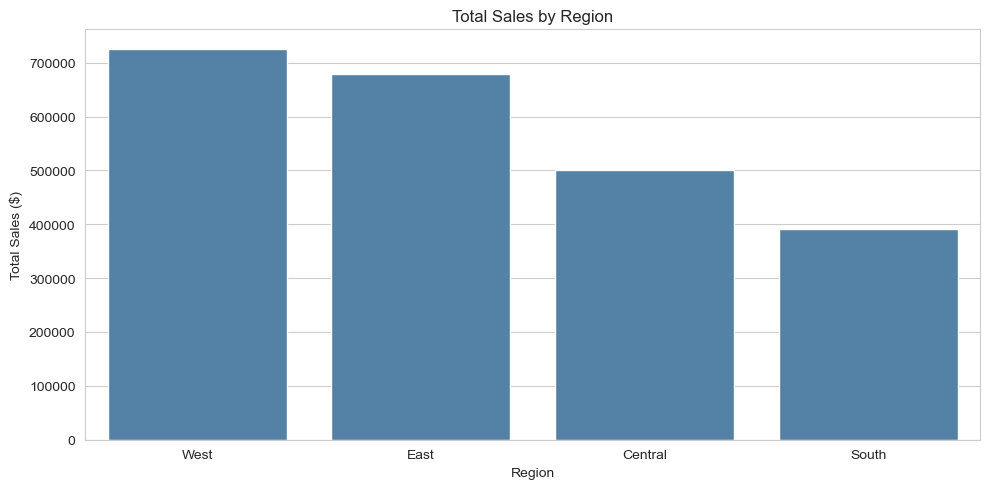

Chart 2 done


In [8]:
# Chart 2 — Sales by Region
region_sales = df.groupby("Region")["Sales"].sum().reset_index()
region_sales = region_sales.sort_values("Sales", ascending=False)

plt.figure()
sns.barplot(data=region_sales, x="Region", y="Sales", color="steelblue")
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales ($)")
plt.tight_layout()
plt.savefig("../region_sales.png")
plt.show()
print("Chart 2 done")

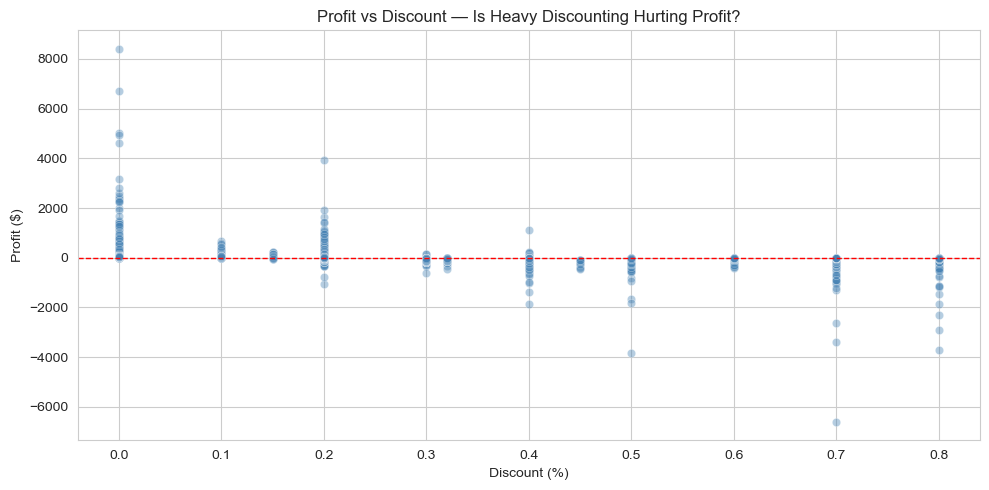

Chart 3 done


In [9]:
# Chart 3 — Profit vs Discount (correlation)
plt.figure()
sns.scatterplot(data=df, x="Discount", y="Profit", alpha=0.4, color="steelblue")
plt.title("Profit vs Discount — Is Heavy Discounting Hurting Profit?")
plt.xlabel("Discount (%)")
plt.ylabel("Profit ($)")
plt.axhline(y=0, color="red", linestyle="--", linewidth=1)
plt.tight_layout()
plt.savefig("../profit_vs_discount.png")
plt.show()
print("Chart 3 done")

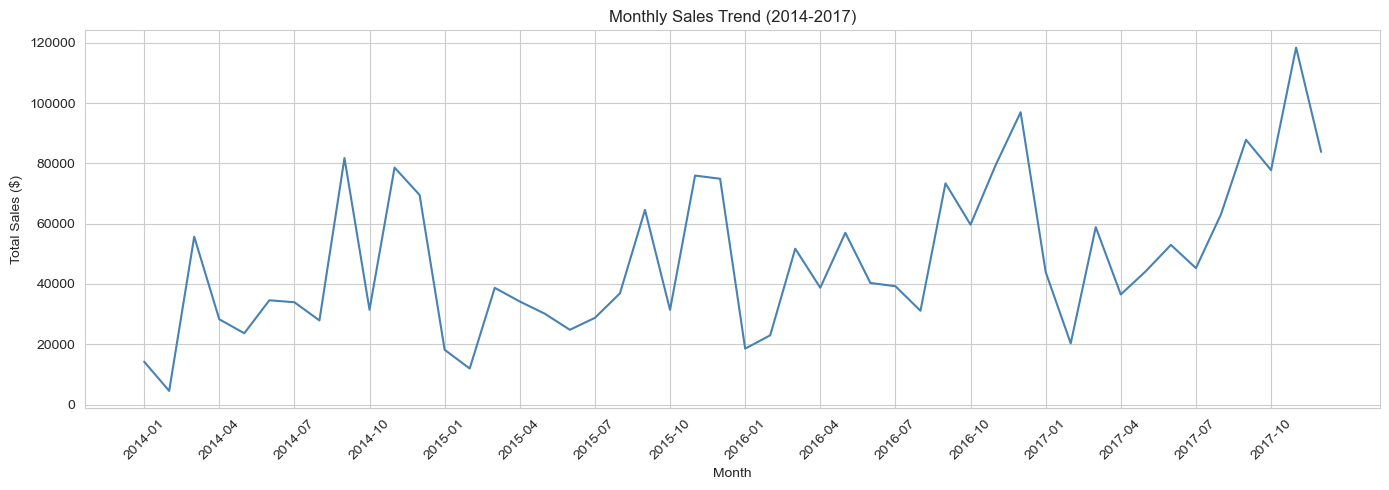

Chart 4 done


In [10]:
# Chart 4 — Monthly sales trend
df["Order Date"] = pd.to_datetime(df["Order Date"])
monthly = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum().reset_index()
monthly["Order Date"] = monthly["Order Date"].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly["Order Date"], monthly["Sales"], color="steelblue", linewidth=1.5)
plt.title("Monthly Sales Trend (2014-2017)")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.xticks(monthly["Order Date"][::3], rotation=45)
plt.tight_layout()
plt.savefig("../monthly_trend.png")
plt.show()
print("Chart 4 done")

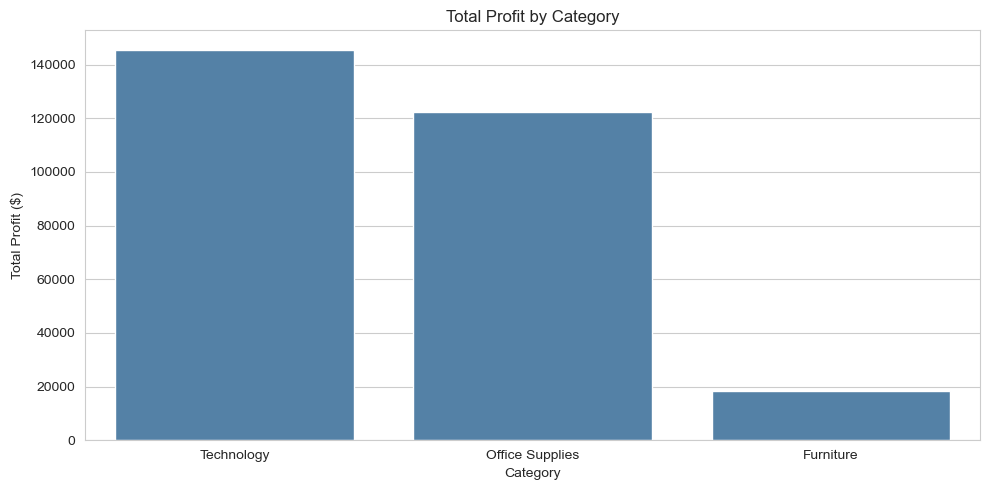

Chart 5 done


In [11]:
# Chart 5 — Profit by Category
category_profit = df.groupby("Category")["Profit"].sum().reset_index()
category_profit = category_profit.sort_values("Profit", ascending=False)

plt.figure()
sns.barplot(data=category_profit, x="Category", y="Profit", color="steelblue")
plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit ($)")
plt.tight_layout()
plt.savefig("../category_profit.png")
plt.show()
print("Chart 5 done")

In [12]:
# Statistical Insights

# 1. Correlation between discount and profit
correlation = df["Discount"].corr(df["Profit"])
print(f"Correlation between Discount and Profit: {correlation:.4f}")

# 2. Profit margin by category
df["Profit Margin"] = df["Profit"] / df["Sales"]
category_margin = df.groupby("Category")["Profit Margin"].mean() * 100
print(f"\nAverage Profit Margin by Category (%):")
print(category_margin.round(2))

# 3. Outlier detection using IQR on Sales
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df["Sales"] < lower) | (df["Sales"] > upper)]
print(f"\nSales Outliers detected: {len(outliers)} orders")
print(f"IQR Range: ${lower:.2f} to ${upper:.2f}")

# 4. Skewness
print(f"\nSales skewness: {df['Sales'].skew():.4f}")
print(f"Profit skewness: {df['Profit'].skew():.4f}")

Correlation between Discount and Profit: -0.2195

Average Profit Margin by Category (%):
Category
Furniture           3.88
Office Supplies    13.80
Technology         15.61
Name: Profit Margin, dtype: float64

Sales Outliers detected: 1167 orders
IQR Range: $-271.71 to $498.93

Sales skewness: 12.9728
Profit skewness: 7.5614


## Key Statistical Insights

### 1. Discount vs Profit Correlation: -0.22
Negative correlation confirms that higher discounts lead to lower profit.
While the correlation is moderate (-0.22), the scatter plot shows orders 
with discounts above 40% almost always result in negative profit.
**Recommendation:** Cap discounts at 30% to protect margins.

### 2. Profit Margin by Category
- Technology: 15.61% — highest margin, most efficient category
- Office Supplies: 13.80% — solid performer
- Furniture: 3.88% — critically low margin, likely due to heavy discounting
**Recommendation:** Investigate Furniture discounting practices — 
3.88% margin leaves almost no room for error.

### 3. Sales Outliers: 1,167 orders (11.7% of all orders)
Over 11% of orders are statistical outliers in terms of sales value.
These high-value orders disproportionately impact total revenue figures
and should be tracked separately for forecasting purposes.

### 4. Skewness
- Sales skewness: 12.97 (extremely right-skewed)
- Profit skewness: 7.56 (heavily right-skewed)
Both distributions are heavily skewed — median is more representative 
than mean for both metrics. A small number of very large orders 
drive a disproportionate share of revenue and profit.

In [13]:
# Summary statistics for README
print("=== PROJECT SUMMARY ===")
print(f"Total Orders: {len(df):,}")
print(f"Total Sales: ${df['Sales'].sum():,.2f}")
print(f"Total Profit: ${df['Profit'].sum():,.2f}")
print(f"Overall Profit Margin: {(df['Profit'].sum()/df['Sales'].sum()*100):.2f}%")
print(f"Best Region (Sales): {df.groupby('Region')['Sales'].sum().idxmax()}")
print(f"Best Category (Profit): {df.groupby('Category')['Profit'].sum().idxmax()}")
print(f"Most Profitable Product: {df.groupby('Product Name')['Profit'].sum().idxmax()}")

=== PROJECT SUMMARY ===
Total Orders: 9,994
Total Sales: $2,297,200.86
Total Profit: $286,397.02
Overall Profit Margin: 12.47%
Best Region (Sales): West
Best Category (Profit): Technology
Most Profitable Product: Canon imageCLASS 2200 Advanced Copier
